### Con este notebook, el objetivo es entender desde donde se mueven los estudiantes hacia cartagena


##### Este análisis puede ser muy interesnate si se quisiera reducir el uso de transporte privado, viendo desde que zonas hay más movilidad y con los horarios vistos previamente, se podrían añadir nuevas rutas de trasnporte publico.

Preparamos los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import os


def cargar_todo(anios):
    dfs = []
    for anio in anios:
        ruta = f'..//data//viajes_murcia_cartagena_{anio}.parquet'
        if os.path.exists(ruta):
            df = pd.read_parquet(ruta)
            # Limpieza y conversión
            df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m%d')
            df['periodo'] = df['periodo'].astype(int)
            df['viajes'] = pd.to_numeric(df['viajes'], errors='coerce').fillna(0)
            df['mes'] = df['fecha'].dt.month
            df['anio'] = anio
            df['origen'] = df['origen'].astype(str).str.strip()
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

diccionario_origenes = {
    '3003001': 'Murcia D1 (San Antón / San Andrés)',
    '3003002': 'Murcia D2 (La Flota / La Fama)',
    '3003003': 'Murcia D3 (El Carmen / Infante)',
    '3003004': 'Murcia D4 (Churra / Cabezo de Torres)',
    '3003005': 'Murcia D5 (El Palmar / La Alberca)',
    '3003006': 'Murcia D6 (Beniaján / Los Dolores)',
    '3003007': 'Murcia D7 (La Ñora / Guadalupe)',
    '3003008': 'Murcia D8 (Corvera / Sucina)',
    '30027': 'Molina de Segura',
    '30005': 'Alcantarilla',
    '30035': 'San Javier',
    '30036': 'San Pedro del Pinatar',
    '3003701': 'Torre-Pacheco D1 (Centro)',
    '3003702': 'Torre-Pacheco D2 (Roldán / Balsicas)',
    '30902': 'Los Alcázares'
}

# Creamos una nueva variable que contenga todas las salidas desde cada zona hacia antigones
df_total = cargar_todo([2022, 2023, 2024, 2025])
df_total['nombre_origen'] = df_total['origen'].map(diccionario_origenes)
flujo_origenes = df_total.groupby('nombre_origen')['viajes'].sum().reset_index()
flujo_origenes = flujo_origenes.sort_values(by='viajes', ascending=False)

In [2]:
df_total['distancia'].value_counts()

distancia
10-50    7309
>50       539
Name: count, dtype: int64

### **Ranking de Origenes**

C:\Users\beltr\AppData\Local\Temp\ipykernel_12248\2613250714.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_flujo, x='viajes', y='nombre_origen', palette='viridis')


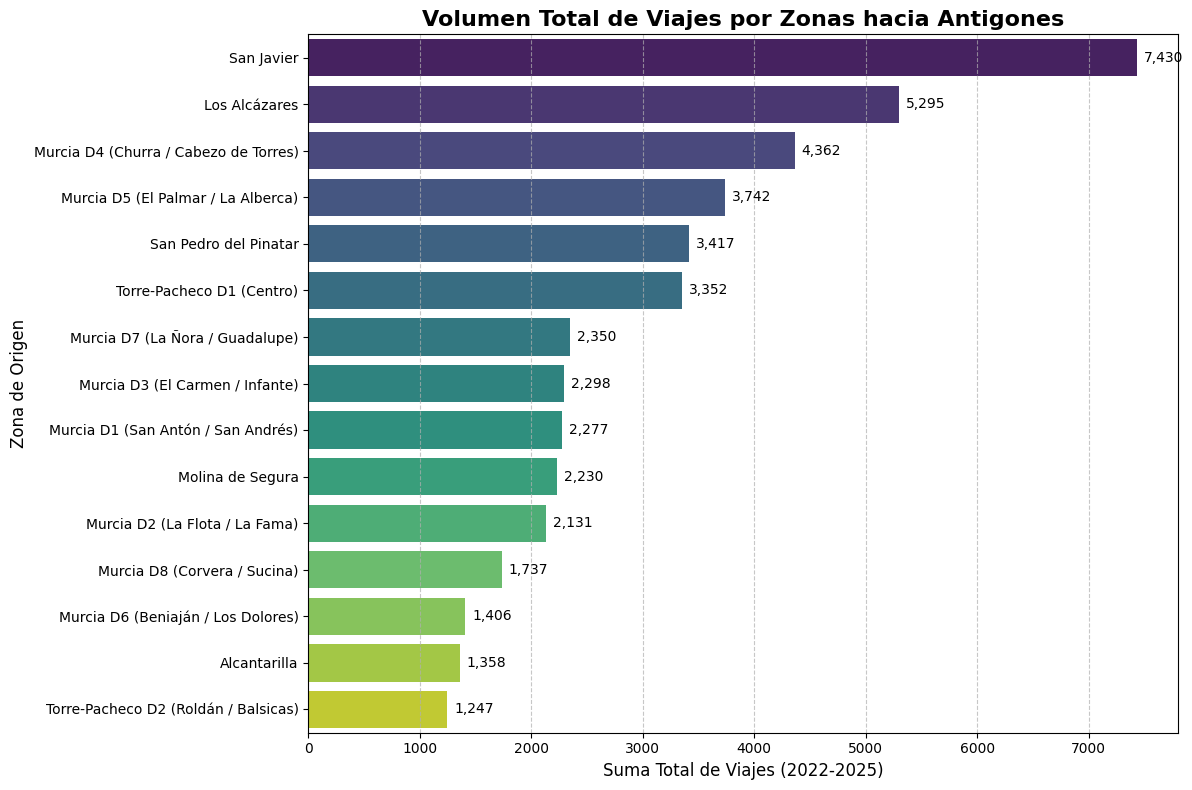

In [3]:
def graficar_ranking_origenes(df_flujo):
    plt.figure(figsize=(12, 8))
    
    # Creamos el gráfico de barras horizontales
    ax = sns.barplot(data=df_flujo, x='viajes', y='nombre_origen', palette='viridis')
    
    plt.title('Volumen Total de Viajes por Zonas hacia Antigones', fontsize=16, weight='bold')
    plt.xlabel('Suma Total de Viajes (2022-2025)', fontsize=12)
    plt.ylabel('Zona de Origen', fontsize=12)
    
    # Añadimos los valores exactos a la derecha de cada barra para mayor rigor
    for i in ax.containers:
        ax.bar_label(i, fmt='{:,.0f}', padding=5, color='black', fontsize=10)
        
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

graficar_ranking_origenes(flujo_origenes)

Es un gráfico muy interesante de las zonas con mayor movilidad, a este hay que añadirle el gráfico interactivo de Ktherine

### **Gráfico Sankey**

In [4]:
def graficar_sankey_flujos(df_flujo):
    # 1. Definimos los Nodos
    # Todos los orígenes + 1 destino final (Campus Antigones)
    nombres_nodos = df_flujo['nombre_origen'].tolist() + ['Campus Antigones (UPCT)']
    
    # El índice del destino es el último elemento de la lista
    indice_destino = len(nombres_nodos) - 1
    
    # 2. Preparamos las conexiones (Source, Target, Value)
    fuentes = list(range(len(df_flujo))) # Índices de 0 a 14 (los orígenes)
    destinos = [indice_destino] * len(df_flujo) # Todos apuntan al índice 15 (Antigones)
    valores = df_flujo['viajes'].tolist() # El grosor de la línea
    
    # 3. Asignación estratégica de colores
    colores_enlaces = []
    for origen in df_flujo['nombre_origen']:
        if 'Murcia' in origen or 'Alcantarilla' in origen or 'Molina' in origen:
            # Tonos azules/verdosos para el eje interior
            colores_enlaces.append('rgba(50, 130, 184, 0.5)')
        else:
            # Tonos cálidos/naranjas para el eje Mar Menor/Campo de Cartagena
            colores_enlaces.append('rgba(243, 113, 33, 0.5)')
            
    # Color de los rectángulos (nodos)
    colores_nodos = ['#1B262C'] * len(nombres_nodos) 
    colores_nodos[-1] = '#B22222' # Destino final en un color rojo universitario para destacar

    # 4. Creación del Gráfico Plotly
    fig = go.Figure(data=[go.Sankey(
        node = dict(
            pad = 20, # Espacio vertical entre nodos
            thickness = 25, # Grosor del nodo
            line = dict(color = "black", width = 0.5),
            label = nombres_nodos,
            color = colores_nodos
        ),
        link = dict(
            source = fuentes,
            target = destinos,
            value = valores,
            color = colores_enlaces
        )
    )])

    fig.update_layout(
        title_text="Flujo de Movilidad Estudiantil hacia el Campus Antigones (UPCT)", 
        font_size=12,
        height=700, # Altura generosa para que quepan todos los textos
        margin=dict(t=50, l=50, r=50, b=50)
    )
    
    fig.show()

graficar_sankey_flujos(flujo_origenes)

Usamos un gráfico de Sankey, una herramiento muy interesante para entender el flujo de movimiento desde Murcia a Caratgena. Donde el grosor de cada barra demuestra la importancia que tiene.

Destacamos como de los dsitritos de murcia los dos más influyenes son Churra y cabezo de torres, mientras que alcantarilla o la zona de lso dolores y beniaján hay muy poca influencia.

Respecto los campos de cartagtena, hay una grán ifluencia por parte de San Javier y alrededores, pero por otro lado, tenemos la zona de Balsicas, con un ídnice bajisimo de estudiantes.